# The chain problem
The 5-state Chain problem [Strens,2000], requires the MDP agent to select between
two abstract actions {1, 2}. Action 1 causes the agent to move to the
right with probability 0.8 and causes the agent to reset to the initial state with probability 0.2. Action 2 causes the agent to reset with probability 0.8 and causes the agent to move to the right with probability 0.2. The action b has constant reward of +2. Rewards vary based on the state and effect (“a” and “b”).
The optimal policy is to always choose action 1, causing the agent to potentially receive +10 several times until slipping back (randomly) to the initial state. Of course if the transition probabilities and rewards are not known, the agent has to trade-off exploration and exploitation to learn this optimal policy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

dir_name = 'chain'
os.makedirs(dir_name, exist_ok = True)

## 1. Dynamic Programming solution

In [2]:
def plot_chain(V, pi, gradient, actions):
    if gradient:
        display_grid = V
        cmap = 'viridis'
        vmin = np.min(V)
        vmax = np.max(V)
    else:
        cmap = 'gray'
        vmin = 0
        vmax = 1
        display_grid = np.ones_like(V)

    rows, cols = V.shape
    if actions:
        fig, ax = plt.subplots(figsize=(cols * 1.2, rows * 1.2))
    else:
        fig, ax = plt.subplots(figsize=(cols * 1.1, rows * 1.1))

    ax.imshow(display_grid, cmap=cmap, vmin=vmin, vmax=vmax, alpha=1)
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color='black', linewidth=1.5)
    ax.tick_params(which='minor', size=0)
    if actions:
        arrow_scale = 0.3
        head_size = 0.15
        for i in range(rows):
            for j in range(cols):
                dx, dy = 0, 0
                if pi[j] == 0:    # right
                    dx = arrow_scale
                elif pi[j] == 1:  # reset
                    dx = -arrow_scale
                ax.arrow(
                    j - dx * 0.5,
                    i - dy * 0.5,
                    dx,
                    dy,
                    head_width=head_size,
                    head_length=head_size,
                    fc='black',
                    ec='black',
                    linewidth=1.5,
                    length_includes_head=True,
                    zorder=2
                )
    else:
        for i in range(rows):
            for j in range(cols):
                ax.text(j, i, str(round(V[i, j], 3)),
                        ha='center', va='center',
                        fontsize=int(12. / cols * 5), color='black')
        plt.colorbar(ax.images[0], ax=ax,label='V estimate')

    plt.tight_layout()
    plt.show()

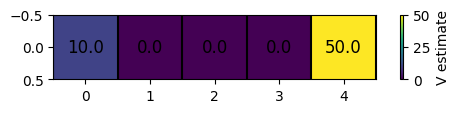

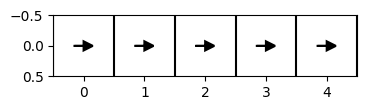

In [3]:
# initialization
chain_length = 5
V = np.zeros(chain_length)
pi = np.random.randint(2,size = chain_length)   # initialize actions randomly as 0 (left) or 1 (right)
gamma = 0.8

####################
# POLICY ITERATION #
#################### 

policy_stable = False
while policy_stable == False:
    theta = 0.25   # accuracy thresh
    delta = 0.5
    while delta > theta:
        delta = 0
        theta = 10.
        # loop across states
        for state in range(chain_length):
            action = pi[state]
            v = V[state]

            if action == 0:  # move right with p=0.8, reset p = 0.2
                rand = np.random.uniform(0,1)
                if rand <= 0.8:
                    state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10  # no reward for moving on right (10 if last state)
                else:
                    state = 0
                    r = 2  # reset leads reward 2
            if action == 1:  # move right with p=0.2, reset p = 0.8
                rand = np.random.uniform(0,1)
                if rand <= 0.2:
                    state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10 # no reward for moving on right (10 if last state)
                else:
                    state = 0
                    r = 2  # reset leads reward 2
            V[state] = r + gamma * V[state]
            delta = max(delta, abs(v-V[state]))
            #print(delta)
            
    # POLICY IMPROVEMENT LOOP
    policy_stable = True
    for state in range(chain_length):
        old_action = pi[state]

        # check all actions
        temp = []
        valid_actions = []
        for action_idx in range(chain_length):
            
            if action_idx == 0:  # move right with p=0.8, reset p = 0.2
                rand = np.random.uniform(0,1)
                if rand <= 0.8:
                    state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10  # no reward for moving on right (10 if last state)
                else:
                    state = 0
                    r = 2  # reset leads reward 2
            if action_idx == 1:  # move right with p=0.2, reset p = 0.8
                rand = np.random.uniform(0,1)
                if rand <= 0.2:
                    state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10 # no reward for moving on right (10 if last state)
                else:
                    state = 0
                    r = 2  # reset leads reward 2
            temp.append(r+gamma * V[state])
            valid_actions.append(action_idx)

            best_action = valid_actions[np.argmax(np.array(temp))]
            pi[state] = best_action
            if best_action != old_action:
                policy_stable = False
    #print(pi)
plot_chain(V.reshape(1,chain_length),pi,gradient = True,actions = False)
plot_chain(V.reshape(1,chain_length),pi,gradient = False,actions = True)

## 1.1: Cumulative Reward estimate over time with best policy

In [4]:
def policy_estimator(pi,chain_length,max_iter,plot_flag,path,tipo):
    state = 0 # initial state
    rewards = []
    times = []
    
    for t in range(max_iter):
        action = pi[state]
        if action == 0:  # move right with p=0.8, reset p = 0.2
            rand = np.random.uniform(0,1)
            if rand <= 0.8:
                state = min(state + 1,chain_length-1)
                r = 0 if state != chain_length-1 else 10  # no reward for moving on right (10 if last state)
            else:
                state = 0
                r = 2  # reset leads reward 2
        if action == 1:  # move right with p=0.2, reset p = 0.8
            rand = np.random.uniform(0,1)
            if rand <= 0.2:
                state = min(state + 1,chain_length-1)
                r = 0 if state != chain_length-1 else 10 # no reward for moving on right (10 if last state)
            else:
                state = 0
                r = 2  # reset leads reward 2
        rewards.append(r)
        times.append(t)

    cum_r = np.cumsum(rewards)
    if plot_flag:
        plt.plot(times[1:], cum_r[1:] / np.array(times)[1:],label = f'avg reward {tipo}')
        plt.xlabel('time')
        plt.ylabel('mean R')
        plt.grid(alpha = 0.6)
        plt.legend()
        plt.savefig(path)
        plt.show()
    
    return times, rewards, cum_r, cum_r[1:] / np.array(times[1:])

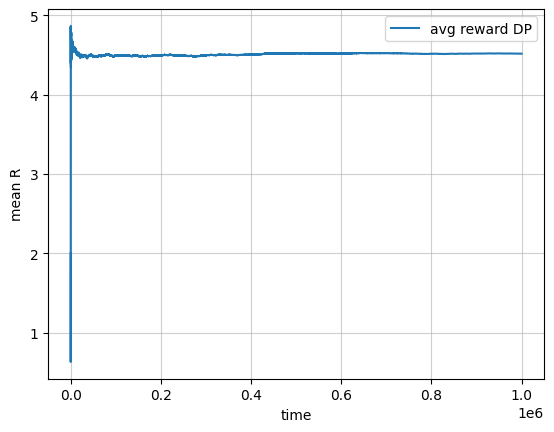

In [5]:
max_iter = int(1e6)
path = dir_name +'/DP_reward.png'
t_DP,r_DP,cum_r_DP,avg_cum_r_DP = policy_estimator(pi,chain_length,max_iter,plot_flag = True,path=path,tipo='DP')

In [6]:
best_R = avg_cum_r_DP[-1]
print(f'best average Reward for unit time is {round(best_R,3)}')

best average Reward for unit time is 4.515


## 2: Monte Carlo solution (exploring starts)

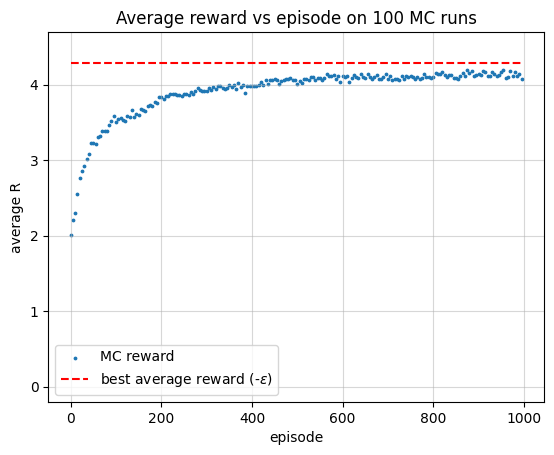

In [7]:
# initialization
chain_length = 5
n_runs = 100
total_episodes = int(1e3)
modulo = int(total_episodes / 200)
accuracies = np.zeros(int(total_episodes / modulo))

for n_run in range(n_runs):
    Q = np.zeros((chain_length,2))
    pi = np.random.randint(2,size = chain_length)   # initialize actions randomly as 0 (left) or 1 (right)
    gamma = 0.8
    epsilon = 0.05
    
    max_steps = 25    # 2*chain_length**2
    returns = np.zeros((chain_length,2))  # to store returns
    counters = np.zeros((chain_length,2))  # to count how many stored returns
    
    
    acc = []
    pis = []
    episodes = []
    
    start_time = time.time()
    for episode in range(total_episodes):
        # episode initialization
        state = 0
    
        seen_s = []
        seen_a = []
        rewards = []
    
        # loop with monte carlo across the episode
        for _ in range(max_steps):
            # possibility of random action
            rand = np.random.uniform(0,1)
            if rand<epsilon:
                action_index = np.random.randint(2)
            else:
                action_index = pi[state]
            seen_s.append(state)
            seen_a.append(action_index)
    
            # determine outcome of the action
            if action_index == 0:  # move right with p=0.8, reset p = 0.2
                rand = np.random.uniform(0,1)
                if rand <= 0.8:
                    state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10  # no reward for moving on right (10 if last state)
                else:
                    state = 0
                    r = 2  # reset leads reward 2
            if action_index == 1:  # move right with p=0.2, reset p = 0.8
                rand = np.random.uniform(0,1)
                if rand <= 0.2:
                    state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10 # no reward for moving on right (10 if last state)
                else:
                    state = 0
                    r = 2  # reset leads reward 2
    
            # update state and save r
            rewards.append(r)
        # finished episode, now compute returns
        G = 0
        for t in range(max_steps-1,-1,-1):  # reverse index loop
            G = gamma * G + rewards[t]
            st = seen_s[t-1]
            at = seen_a[t-1]
            if (st,at) not in zip(seen_s[:(t-2)],seen_a[:(t-2)]):
                returns[st,at] += G
                counters[st,at] += 1
                Q[st,at] = returns[st,at]/counters[st,at]
                pi[st] = np.argmax(Q[st,:])
                
        # evaluation logic
        if episode % modulo == 0:
            eval_iter = 1000
            _,_,_,avg_cum = policy_estimator(pi,chain_length,eval_iter,plot_flag=False,path=None,tipo = 'MC')
            acc.append(avg_cum[-1])
            episodes.append(episode)
            pis.append(pi)
    # at the end of the run save the data
    accuracies = np.array(acc) / (n_run + 1) + accuracies * (n_run)/(n_run+1)
    
plt.scatter(episodes,accuracies, label = 'MC reward',s=3)
plt.title(f'Average reward vs episode on {n_runs} MC runs')
plt.xlabel('episode')
plt.ylabel('average R')
plt.ylim(-0.2,max(accuracies)+0.5)
plt.hlines(y = best_R*(1.-epsilon), xmin = episodes[0],xmax = episodes[-1],colors = 'red', linestyles = '--', label = r'best average reward (-$\epsilon$)')
plt.legend()
plt.grid(alpha = 0.5)
path = dir_name + f'/MC_avg_reward_{n_runs}_runs.png'
plt.savefig(path)
plt.show()

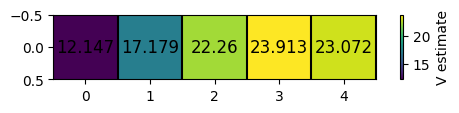

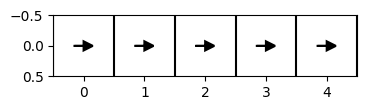

In [8]:
best_Q = np.max(Q,axis = 1)
plot_chain(best_Q.reshape(1,chain_length),pi,gradient = True,actions = False)
plot_chain(best_Q.reshape(1,chain_length),pi,gradient = False,actions = True)

In [9]:
MC_dict = {
    'episodes':episodes,
    'mean_accuracies':accuracies,
    'n_runs':n_runs,
    'n_episodes':total_episodes,
    'epsilon':epsilon,
    'gamma':gamma,
    'best R': best_R,
    'eval_iter':eval_iter
}

In [10]:
log_path = dir_name + '/MC_data.txt'
with open(log_path,"w") as text_file:
    for (key,value) in zip(MC_dict.keys(),MC_dict.values()):
        print(f"{key}: {value}",file = text_file)

# 3: SARSA solution
Behavior of SARSA is interesting in this problem. Being the update immediate, it prefers the reset reward (+2) rather than the long chain reward (+10), interpreted as more risky. Thus, the policy and the estimate of SARSA end up being suboptimal

In [11]:
accuracies = np.zeros(int(total_episodes / modulo))


start_time = time.time()

for n_run in range(n_runs):
    Q = np.zeros((chain_length,2))
    pi = np.ones((chain_length,2)) / 2.   # initialize actions uniformly across all choices
    alpha = 0.1
    max_steps = 25                                  # 2*chain_length**2
    t = 0
    acc = []
    episodes = []
    #print(n_run)
    while t < total_episodes:
        t += 1
        # episode loop
        # initialization
        state = 0
        step_counter = 0
        
        # epsilon greedy choice
        action_idx = np.random.choice(np.arange(0,2,1),p = pi[state,:])  # choose action 0 or 1 according to pi
       
        # loop until end of episode
        while step_counter < max_steps:
            # take such action
            if action_idx == 0:  # move right with p=0.8, reset p = 0.2
                rand = np.random.uniform(0,1)
                if rand <= 0.8:
                    new_state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10  # no reward for moving on right (10 if last state)
                else:
                    new_state = 0
                    r = 2  # reset leads reward 2
            if action_idx == 1:  # move right with p=0.2, reset p = 0.8
                rand = np.random.uniform(0,1)
                if rand <= 0.2:
                    new_state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10 # no reward for moving on right (10 if last state)
                else:
                    new_state = 0
                    r = 2  # reset leads reward 2
    
            # we have state and new state
            step_counter += 1
            # select future action based on new state
            # epsilon greedy
            new_action_idx = np.random.choice(np.arange(0,2,1),p = pi[new_state,:])  # choose action 0 or 1 according to pi
        
            # update state-action value
            Q[state,action_idx] = Q[state,action_idx]+ alpha * (r + gamma * Q[new_state,new_action_idx]-Q[state,action_idx]) 
            # update policy according to Q (epsilon greedy)
            best_action = np.argmax(Q[state,:])
            pi[state,:] = epsilon / 2.
            pi[state,best_action] += 1 - epsilon
                
            
            # update state and action
            state = new_state
            action_idx = new_action_idx
    
        if t % modulo == 0:
            pi_eval = np.argmax(pi,axis = 1)
            eval_iter = 1000
            _,_,_,avg_cum = policy_estimator(pi_eval,chain_length,eval_iter,plot_flag=False,path=None,tipo = 'SARSA')
            acc.append(avg_cum[-1])
            episodes.append(t)
    accuracies = np.array(acc) / (n_run + 1) + accuracies * (n_run)/(n_run+1)
        

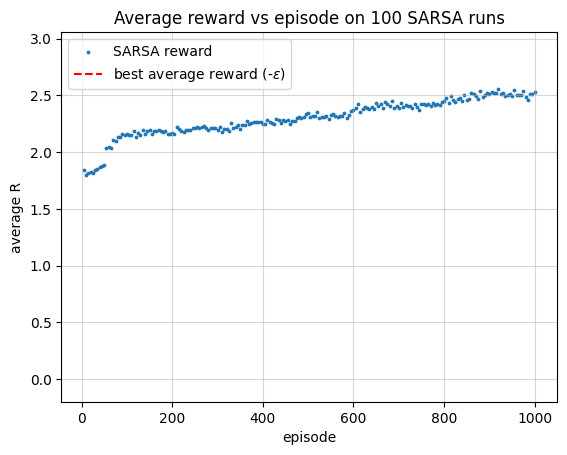

In [12]:
plt.scatter(episodes,accuracies, label = 'SARSA reward',s=3)
plt.title(f'Average reward vs episode on {n_runs} SARSA runs')
plt.xlabel('episode')
plt.ylabel('average R')
plt.ylim(-0.2,max(accuracies)+0.5)
plt.hlines(y = best_R*(1.-epsilon), xmin = episodes[0],xmax = episodes[-1],colors = 'red', linestyles = '--', label = r'best average reward (-$\epsilon$)')
plt.legend()
plt.grid(alpha = 0.5)
path = dir_name + f'/SARSA_avg_reward_{n_runs}_runs.png'
plt.savefig(path)
plt.show()

In [13]:
pi

array([[0.025, 0.975],
       [0.025, 0.975],
       [0.025, 0.975],
       [0.025, 0.975],
       [0.975, 0.025]])

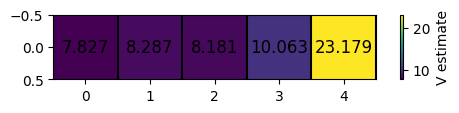

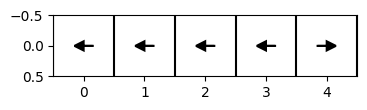

In [14]:
best_Q = np.max(Q,axis = 1)
best_pi = np.argmax(pi,axis = 1)
plot_chain(best_Q.reshape(1,chain_length),best_pi,gradient = True,actions = False)
plot_chain(best_Q.reshape(1,chain_length),best_pi,gradient = False,actions = True)

In [15]:
SARSA_dict = {
    'episodes':episodes,
    'mean_accuracies':accuracies,
    'n_runs':n_runs,
    'n_episodes':total_episodes,
    'epsilon':epsilon,
    'gamma':gamma,
    'best R': best_R,
    'eval_iter':eval_iter
}

In [16]:
log_path = dir_name + '/SARSA_data.txt'
with open(log_path,"w") as text_file:
    for (key,value) in zip(SARSA_dict.keys(),SARSA_dict.values()):
        print(f"{key}: {value}",file = text_file)

### Comparison plot

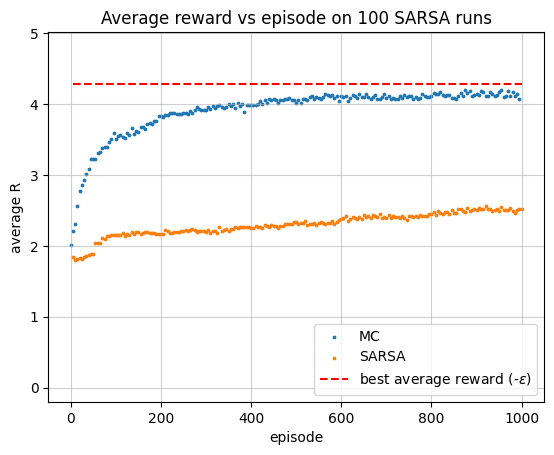

In [17]:
plt.scatter(MC_dict['episodes'],MC_dict['mean_accuracies'],label ='MC',s=3)
plt.scatter(SARSA_dict['episodes'],SARSA_dict['mean_accuracies'],label ='SARSA',s=3)
plt.title(f'Average reward vs episode on {n_runs} SARSA runs')

plt.grid(alpha = 0.6)
plt.hlines(y = best_R*(1.-epsilon), xmin = episodes[0],xmax = episodes[-1],colors = 'red', linestyles = '--', label = r'best average reward (-$\epsilon$)')
plt.xlabel('episode')
plt.ylabel('average R')
plt.ylim(-0.2,best_R+0.5)
plt.legend(loc='lower right')
path = dir_name + f'/MCSARSA_avg_reward_{n_runs}_runs.png'
plt.savefig(path)
plt.show()

# 4: Q-Learning solution
Q-learning is a variation of SARSA in which the next action is not committed in advance, but is chosen maximizing the expected return. In this specific problem, in which looking forward to the best long term return is key, a feature like this may be highly impactful

In [18]:
accuracies = np.zeros(int(total_episodes / modulo))
start_time = time.time()

for n_run in range(n_runs):
    Q = np.zeros((chain_length,2))
    pi = np.ones((chain_length,2)) / 2.   # initialize actions uniformly across all choices
    alpha = 0.1
    max_steps = 25                                  # 2*chain_length**2
    acc = []
    episodes = []
    t = 0
    while t < total_episodes:
        t += 1
        # episode loop
        # initialization
        state = 0
        step_counter = 0
        
        # epsilon greedy choice
        action_idx = np.random.choice(np.arange(0,2,1),p = pi[state,:])  # choose action 0 or 1 according to pi
       
        # loop until end of episode
        while step_counter < max_steps:
            # take such action
            if action_idx == 0:  # move right with p=0.8, reset p = 0.2
                rand = np.random.uniform(0,1)
                if rand <= 0.8:
                    new_state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10  # no reward for moving on right (10 if last state)
                else:
                    new_state = 0
                    r = 2  # reset leads reward 2
            if action_idx == 1:  # move right with p=0.2, reset p = 0.8
                rand = np.random.uniform(0,1)
                if rand <= 0.2:
                    new_state = min(state + 1,chain_length-1)
                    r = 0 if state != chain_length-1 else 10 # no reward for moving on right (10 if last state)
                else:
                    new_state = 0
                    r = 2  # reset leads reward 2
    
            # we have state and new state
            step_counter += 1
            
            # update state-action value with the best future action (np.max(Q[new_state,:],axis = 0))
            Q[state,action_idx] = Q[state,action_idx]+ alpha * (r + gamma * np.max(Q[new_state,:],axis = 0)-Q[state,action_idx]) 
            # update policy according to Q (epsilon greedy)
            best_action = np.argmax(Q[state,:])
            pi[state,:] = epsilon / 2.
            pi[state,best_action] += 1 - epsilon
                
            
            # update state and action
            state = new_state
            
        if t % modulo == 0:
            pi_eval = np.argmax(pi,axis = 1)
            eval_iter = 10000
            _,_,_,avg_cum = policy_estimator(pi_eval,chain_length,eval_iter,plot_flag=False,path=None,tipo = 'SARSA')
            acc.append(avg_cum[-1])
            episodes.append(t)
    accuracies = np.array(acc) / (n_run + 1) + accuracies * (n_run)/(n_run+1)
        


KeyboardInterrupt



In [ ]:
Qlearning_dict = {
    'episodes':episodes,
    'mean_accuracies':accuracies,
    'n_runs':n_runs,
    'n_episodes':total_episodes,
    'epsilon':epsilon,
    'gamma':gamma,
    'best R': best_R,
    'eval_iter':eval_iter
}

log_path = dir_name + '/Qlearning_data.txt'
with open(log_path,"w") as text_file:
    for (key,value) in zip(Qlearning_dict.keys(),Qlearning_dict.values()):
        print(f"{key}: {value}",file = text_file)

In [ ]:
plt.scatter(MC_dict['episodes'],MC_dict['mean_accuracies'],label ='MC',s=3)
plt.scatter(SARSA_dict['episodes'],SARSA_dict['mean_accuracies'],label ='SARSA',s=3)
plt.scatter(Qlearning_dict['episodes'],Qlearning_dict['mean_accuracies'],label ='Q Learning',s=3)
plt.title(f'Average reward vs episode on {n_runs} Q-Learning runs')

plt.grid(alpha = 0.6)
plt.hlines(y = best_R*(1.-epsilon), xmin = episodes[0],xmax = episodes[-1],colors = 'red', linestyles = '--', label = r'best $<R>$ (-$\epsilon$)')
plt.xlabel('episode')
plt.ylabel('average R')
plt.ylim(-0.2,best_R+0.5)
plt.legend(loc='lower right')
path = dir_name + f'/MCSARSAQL_avg_reward_{n_runs}_runs.png'
plt.savefig(path)
plt.show()

In [ ]:
best_Q = np.max(Q,axis = 1)
best_pi = np.argmax(pi,axis = 1)
plot_chain(best_Q.reshape(1,chain_length),best_pi,gradient = True,actions = False)
plot_chain(best_Q.reshape(1,chain_length),best_pi,gradient = False,actions = True)

# 5 Bayesian Solution

In [19]:
def value_iteration(P, R, gamma, n_states, n_actions, n_iter=50):
    V = np.zeros(n_states)
    for _ in range(n_iter):
        Q = np.zeros((n_states, n_actions))
        for s in range(n_states):
            for a in range(n_actions):
                Q[s,a] = np.sum(P[s,a,:] * (R[s,a,:] + gamma * V))
        V = np.max(Q, axis=1)
    return Q

def bayesian_chain(chain_length=5,
                   total_episodes=1000,
                   gamma=0.8,
                   max_steps=25,
                   modulo = 20):

    n_states = chain_length
    n_actions = 2
    
    # Dirichlet prior over transitions
    # alpha[s,a,s'] counts transitions
    alpha = np.ones((n_states, n_actions, n_states))
    
    episodes = []
    pis = []
    acc = []
    
    for episode in range(total_episodes):
        
        # ---- 1. Sample MDP from posterior ----
        P_sample = np.zeros_like(alpha)
        for s in range(n_states):
            for a in range(n_actions):
                P_sample[s,a,:] = np.random.dirichlet(alpha[s,a,:])
        
        # True reward model (known)
        R = np.zeros((n_states,n_actions,n_states))
        for s in range(n_states):
            for a in range(n_actions):
                for s2 in range(n_states):
                    if s2 == 0 and s != 0:
                        R[s,a,s2] = 2
                    if s == chain_length-1 and s2 == chain_length-1:
                        R[s,a,s2] = 10
        
        # ---- 2. Solve sampled MDP ----
        Q = value_iteration(P_sample, R, gamma,
                            n_states, n_actions)
        policy = np.argmax(Q, axis=1)
        
        # ---- 3. Run episode in real env ----
        state = 0
        cum_reward = 0
        
        for step in range(max_steps):
            
            action = policy[state]
            
            # True environment dynamics (chain)
            if action == 0:
                p_forward = 0.8
            else:
                p_forward = 0.2
            
            if np.random.rand() <= p_forward:
                new_state = min(state+1, chain_length-1)
                r = 10 if state == chain_length-1 else 0
            else:
                new_state = 0
                r = 2
            
            cum_reward += r
            
            # ---- 4. Update posterior ----
            alpha[state,action,new_state] += 1
            
            state = new_state
        
        if episode % modulo == 0:
            pi_eval = policy
            eval_iter = 10000
            _,_,_,avg_cum = policy_estimator(pi_eval,chain_length,eval_iter,plot_flag=False,path=None,tipo = 'Bayesian')
            acc.append(avg_cum[-1])
            episodes.append(episode)
            pis.append(policy)
    
    return episodes, acc, pis

In [20]:
episodes,accuracies,pis = bayesian_chain(chain_length=chain_length,total_episodes=total_episodes,gamma=gamma,max_steps=max_steps,modulo = modulo)

Bayesian_dict = {
    'episodes':episodes,
    'mean_accuracies':accuracies,
    'n_runs':n_runs,
    'n_episodes':total_episodes,
    'epsilon':epsilon,
    'gamma':gamma,
    'best R': best_R,
    'eval_iter':eval_iter
}

log_path = dir_name + '/BayesianInference_data.txt'
with open(log_path,"w") as text_file:
    for (key,value) in zip(Bayesian_dict.keys(),Bayesian_dict.values()):
        print(f"{key}: {value}",file = text_file)

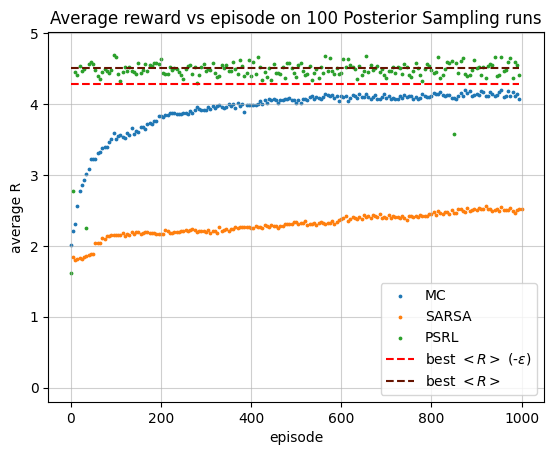

In [24]:
plt.scatter(MC_dict['episodes'],MC_dict['mean_accuracies'],label ='MC',s=3)
plt.scatter(SARSA_dict['episodes'],SARSA_dict['mean_accuracies'],label ='SARSA',s=3)
#plt.scatter(Qlearning_dict['episodes'],Qlearning_dict['mean_accuracies'],label ='Q Learning',s=3)
plt.scatter(Bayesian_dict['episodes'],Bayesian_dict['mean_accuracies'],label ='PSRL',s=3)
plt.title(f'Average reward vs episode on {n_runs} Posterior Sampling runs')
plt.grid(alpha = 0.6)
plt.hlines(y = best_R*(1.-epsilon), xmin = episodes[0],xmax = episodes[-1],colors = 'red', linestyles = '--', label = r'best $<R>$ (-$\epsilon$)')
plt.hlines(y = best_R, xmin = episodes[0],xmax = episodes[-1],colors = '#661400', linestyles = '--', label = r'best $<R>$')
plt.xlabel('episode')
plt.ylabel('average R')
plt.ylim(-0.2,best_R+0.5)
plt.legend(loc='lower right')
path = dir_name + f'/MCSARSAQLBayesianInf_avg_reward_{n_runs}_runs.png'
plt.savefig(path)
plt.show()

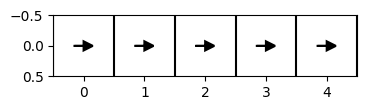

In [22]:

plot_chain(V.reshape(1,chain_length),pis[-1],gradient = False,actions = True)